In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os,sys
import warnings

In [22]:
PROJECT_ROOT = "/home/hushiqi/work/xrs_ana"
SCAN_NAME = "Ho_Comptonscan"
DATA_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "data", SCAN_NAME)
RESULT_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "result")
RESULT_DIR = os.path.join(RESULT_PATH, SCAN_NAME)
SQW_PATH = os.path.join(RESULT_DIR, "result.dat")
os.makedirs(RESULT_DIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-xrsana")
warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, PROJECT_ROOT)

from xrsana import xrs_extraction, xrs_read

Loading HEPS ID33 reduced data : /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho_Comptonscan

Reader summary
scan_name       : Ho_Comptonscan
E0 (keV)        : 9.683032643850813
q average       : 9.58704206984813
tth (deg)       : [155.2971955488892]
eloss shape     : (4001,)
signals shape   : (4001, 1)
errors shape    : (4001, 1)
selected ROIs   : 12
analyzer key    : {'Analyzer01': 0}

Testing edge_extraction handoff...
average signal  : (4001,)
average error   : (4001,)
average q head  : [5.07352433 5.07352433 5.07352433 5.07352433 5.07352433]


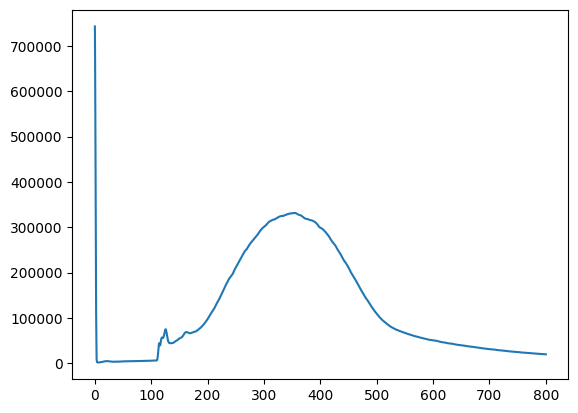

In [23]:
print("Loading HEPS ID33 reduced data :", DATA_PATH)
data = xrs_read.read_heps_id33(DATA_PATH)

print("\nReader summary")
print("scan_name       :", data.scan_name)
print("E0 (keV)        :", data.E0)
print("q average       :", data.q_average)
print("tth (deg)       :", data.tth)
print("eloss shape     :", data.eloss.shape)
print("signals shape   :", data.signals.shape)
print("errors shape    :", data.errors.shape)
print("selected ROIs   :", len(data.selected_rois))
print("analyzer key    :", data.key)
print("\nTesting edge_extraction handoff...")
data_ex = xrs_extraction.edge_extraction(data, ["Ho"], [1.0], {"Ho": ["N5"]})
data_ex.analyzerAverage([0], errorweighing=True)
print("average signal  :", data_ex.avsignals.shape)
print("average error   :", data_ex.averrors.shape)
print("average q head  :", data_ex.avqvals[:5])

plt.plot(data.eloss,data.signals[:,[0]]) #interactive plot window to look at each analyser output 
plt.show()

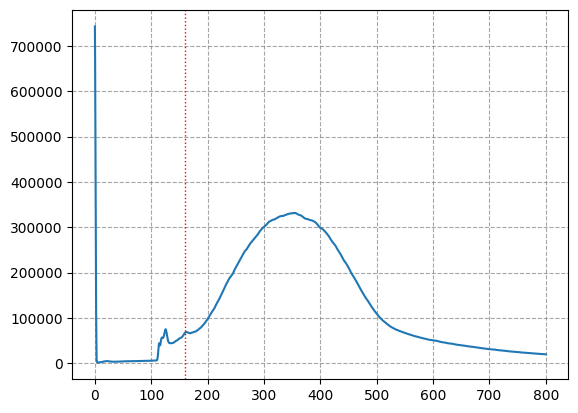

In [24]:
plt.plot(data.eloss, data.signals)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.show()

the fitting results are:  [ 5.31366724e+02  7.11249606e+02  1.63776946e-03 -1.81159880e+01
  9.04953532e+00]


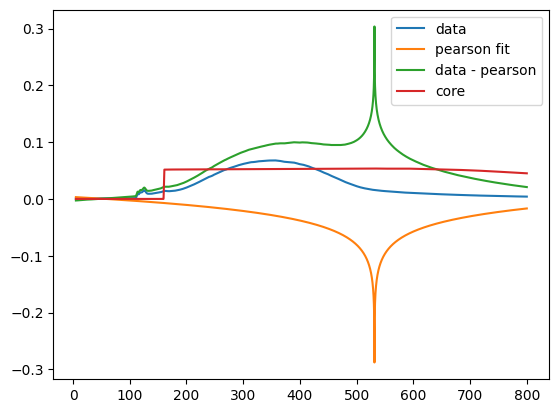

In [25]:
data_ex = xrs_extraction.edge_extraction(data,['Ho'],[1.0],{'Ho':['N4','N5']})
data_ex_cut = data_ex.truncate(5,800, copy_obj=True)
data_ex_cut.analyzerAverage([0],errorweighing=False)
data_ex_cut.removePearsonAv('Ho','N4',[0,100],[600,700],weights=[3,1],HFcore_shift=-4)

In [26]:
data_ex.save_average_Sqw(SQW_PATH, emin=140,emax=180)
data_ex.sqwav

Found no extracted S(q,w).


array([0., 0., 0., ..., 0., 0., 0.], shape=(4001,))

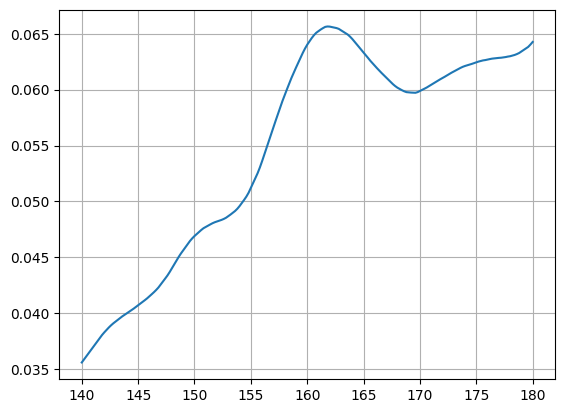

In [27]:
saved_sqw = np.genfromtxt(SQW_PATH, usecols=(0,1))
plt.plot(saved_sqw[:,0], saved_sqw[:,1])
#plt.yscale('log')
plt.grid()
plt.show()